In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# TorchVision
import torchvision.transforms.v2 as v2
from torchvision.models import inception_v3, resnet50, efficientnet_b4, EfficientNet_B4_Weights, ResNet50_Weights, Inception_V3_Weights
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

# Data utilities
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split
from tqdm import tqdm

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


cuda


In [32]:
MAIN_PATH = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\Face Age Dataset"
TRAIN_PATH = os.path.join(MAIN_PATH,"train")
TEST_PATH = os.path.join(MAIN_PATH,"test")

IMG_SIZE = 224

EPOCHS = 10
BATCH_SIZE = 128
PATIENCE = 3

LR = 1e-4

SPLIT_PARAM = [100,25]

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

df = pd.read_csv(os.path.join(MAIN_PATH,"age_detection.csv"))
df

,file,age,split
0,train/18-20/0.jpg,18-20,train
1,train/18-20/1.jpg,18-20,train
2,train/18-20/2.jpg,18-20,train
3,train/18-20/3.jpg,18-20,train
4,train/18-20/4.jpg,18-20,train
...,...,...,...
145,test/51-60/25.jpg,51-60,test
146,test/51-60/26.jpg,51-60,test
147,test/51-60/27.jpg,51-60,test
148,test/51-60/28.jpg,51-60,test


In [33]:
labels = set(df["age"].values)
labels

{'18-20', '21-30', '31-40', '41-50', '51-60'}

In [34]:
df['age'].value_counts()

age
18-20    30
21-30    30
31-40    30
41-50    30
51-60    30
Name: count, dtype: int64

In [35]:
df['split'].value_counts()

split
train    125
test      25
Name: count, dtype: int64

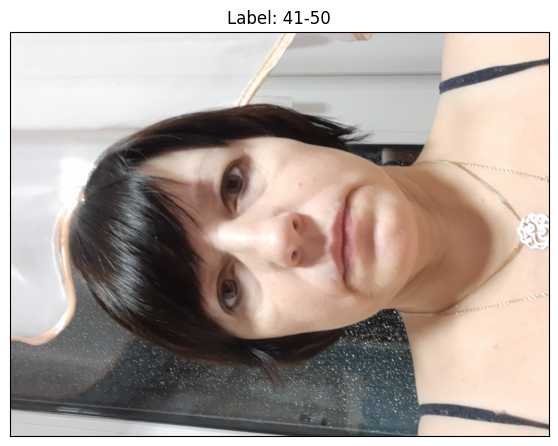

In [36]:
def show_img():
    img_path = np.random.choice(df["file"].values)
    plt.imshow(plt.imread(os.path.join(MAIN_PATH,img_path)))
    plt.title(f"Label: {img_path.split('/')[1]}")
    plt.tight_layout()
    plt.yticks([])
    plt.xticks([])
    plt.show()

show_img()

In [37]:
def get_transforms(size=IMG_SIZE, apply_on_train=False):
    """
    Return a transform pipeline for the given split.

    Parameters
    ----------
    size           : int  — target image size (default 224)
    apply_on_train : bool — whether to include data augmentation
    """
    base = [
        v2.Resize((size, size)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ]

    augmentation = [
        v2.ColorJitter((0.8, 1.3)),
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(90),
    ]

    tail = [
        v2.Normalize(MEAN, STD),
    ]

    if apply_on_train:
        return v2.Compose(base + augmentation + tail)
    return v2.Compose(base + tail)


In [38]:
train_dataset = ImageFolder(TRAIN_PATH,get_transforms(224))
test_ds = ImageFolder(TEST_PATH,get_transforms(224))

In [39]:
torch.manual_seed(42)
train_ds , val_ds = random_split(train_dataset,SPLIT_PARAM)

In [40]:
train_ds.transform = get_transforms(224,True)
train_ds.transform

Compose(
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToImage()
      ToDtype(scale=True)
      ColorJitter(brightness=(0.8, 1.3))
      RandomHorizontalFlip(p=0.5)
      RandomRotation(degrees=[-90.0, 90.0], interpolation=InterpolationMode.NEAREST, expand=False, fill=0)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [41]:
test_ds.transform

Compose(
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [42]:
val_ds.dataset.transform

Compose(
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [44]:
train_ds.dataset.classes

['18-20', '21-30', '31-40', '41-50', '51-60']

In [ ]:
train_dl = DataLoader(train_ds,BATCH_SIZE,True,num_workers=4,pin_memory=True)
val_dl = DataLoader(val_ds,BATCH_SIZE,False,num_workers=4,pin_memory=True)
test_dl = DataLoader(test_ds,BATCH_SIZE,False,num_workers=4,pin_memory=True)